# ClosetAI · Gap analysis del guardaroba
## Rete neurale multi-label su dati aggregati

**Stato nel prodotto:** modello di produzione. Il checkpoint
`ml/weights/gap_model.pt` alimenta la sezione “Cosa manca davvero?”
della dashboard; se non è disponibile, il backend torna a regole
esperte trasparenti.

**Domanda:** il guardaroba presenta uno o più vuoti funzionali?
Ogni riga rappresenta un intero guardaroba, non una singola foto.

## Passo 1 — Individuare il progetto e fissare la riproducibilità

**Obiettivo.** Rendere il notebook indipendente dalla cartella da cui
viene avviato e ottenere risultati ripetibili.

**Cosa fa la cella.** Trova la radice del repository e imposta il seed
condiviso. Questo permette di aprire il file direttamente dalla
pagina ML Lab in VS Code senza dover cambiare manualmente directory.

**Cosa osservare.** Il percorso stampato deve coincidere con la
cartella principale di ClosetAI.

In [1]:
# Trova la radice del repository anche se Jupyter parte da una sottocartella.
from pathlib import Path

def find_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "backend" / "pyproject.toml").is_file() and (candidate / "ml").is_dir():
            return candidate
    raise FileNotFoundError("Radice di ClosetAI non trovata")

ROOT = find_project_root()
SEED = 42
print(f"Repository: {ROOT}")

Repository: C:\devel\closet-ai


## Passo 2 — Caricare il dataset e definire input e output

**Obiettivo.** Trasformare ogni guardaroba simulato in un problema
numerico dichiarato.

**Cosa fa la cella.** Carica il CSV, seleziona 14 feature aggregate e
sei label binarie. Le feature descrivono quantità, proporzioni,
varietà cromatica, presenza di neutri e quota di ghost garments.

**Cosa osservare.** Forma della matrice `X`, forma della matrice `Y` e
prevalenza di ogni label. Classi molto rare richiedono particolare
attenzione quando si leggono le metriche.

In [2]:
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, hamming_loss

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(1)

FEATURES = [
    "n_top", "n_bottom", "n_outerwear", "n_shoes", "n_dress", "n_accessory",
    "n_total", "frac_tshirt", "frac_outerwear", "frac_winter", "frac_formal",
    "n_colors", "has_neutral", "ghost_ratio",
]
LABELS = [
    "manca_capospalla", "manca_scarpe", "manca_formale",
    "manca_invernale", "troppe_tshirt", "poca_varieta_colori",
]

path = ROOT / "ml" / "datasets" / "wardrobe" / "wardrobe_dataset.csv"
df = pd.read_csv(path)
X = df[FEATURES].to_numpy(dtype="float32")
Y = df[LABELS].to_numpy(dtype="float32")
print(f"Guardaroba simulati: {len(df):,} · feature: {X.shape[1]} · label: {Y.shape[1]}")
(df[LABELS].mean().sort_values(ascending=False) * 100).round(1).rename("% positivi").to_frame()

Guardaroba simulati: 5,000 · feature: 14 · label: 6


,% positivi
manca_capospalla,64.6
manca_invernale,40.2
manca_formale,36.9
manca_scarpe,30.5
poca_varieta_colori,26.5
troppe_tshirt,24.6


## Passo 3 — Capire perché il problema è multi-label

**Obiettivo.** Scegliere una formulazione coerente con il prodotto.

Le sei uscite hanno una sigmoid indipendente: lo stesso guardaroba
può contemporaneamente avere poche scarpe, poca varietà cromatica e
troppi top. Una softmax sarebbe sbagliata perché imporrebbe una sola
classe.

Le label sono generate da regole esperte su profili sintetici. La
rete dimostra la pipeline e può apprendere interazioni, ma **non prova
che quei criteri siano universalmente corretti**. Con dati reali,
servirebbero feedback degli utenti e una nuova validazione.

**Cosa osservare.** Ogni riga di `Y` contiene sei valori 0/1 e può
avere più di un 1. Per questo usiamo sei sigmoid indipendenti e non
una softmax, che obbligherebbe il modello a scegliere un solo gap.

## Passo 4 — Creare gli split, normalizzare e definire la rete

**Obiettivo.** Preparare dati comparabili senza leakage e costruire
la MLP usata dal backend.

**Cosa fa la cella.** Genera uno split deterministico 70/15/15. Media
e deviazione vengono calcolate soltanto sul training set e applicate
anche a validation e test. La rete è `14 → 64 → 32 → 6` con ReLU e
Dropout.

**Cosa osservare.** Dimensione dei tre split e numero di parametri.
Se usassimo tutto il dataset per la normalizzazione, informazioni del
test entrerebbero indirettamente nel training.

In [3]:
# Split deterministico 70/15/15. Media e deviazione sono calcolate
# SOLO sul train per evitare leakage statistico.
rng = np.random.default_rng(SEED)
order = rng.permutation(len(X))
n_test = int(len(X) * 0.15)
n_val = int(len(X) * 0.15)
test_idx = order[:n_test]
val_idx = order[n_test:n_test+n_val]
train_idx = order[n_test+n_val:]

mean = X[train_idx].mean(axis=0)
std = X[train_idx].std(axis=0) + 1e-6

def tx(indices):
    return (
        torch.tensor((X[indices] - mean) / std, dtype=torch.float32),
        torch.tensor(Y[indices], dtype=torch.float32),
    )

Xtr, Ytr = tx(train_idx); Xva, Yva = tx(val_idx); Xte, Yte = tx(test_idx)
print("train", len(train_idx), "validation", len(val_idx), "test", len(test_idx))

def build_model():
    return nn.Sequential(
        nn.Linear(14, 64), nn.ReLU(), nn.Dropout(0.20),
        nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.20),
        nn.Linear(32, 6),
    )

model = build_model()
print(f"Parametri addestrabili: {sum(p.numel() for p in model.parameters()):,}")
model

train 3500 validation 750 test 750
Parametri addestrabili: 3,238


Sequential(
  (0): Linear(in_features=14, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=6, bias=True)
)

## Passo 5 — Addestrare le sei uscite con early stopping

**Obiettivo.** Imparare contemporaneamente i sei gap mantenendo
separata la validation.

**Cosa fa la cella.** `BCEWithLogitsLoss` combina sigmoid e binary
cross-entropy in forma numericamente stabile. Adam aggiorna i pesi;
l'early stopping conserva il modello con validation loss minima.

**Cosa osservare.** Epoca di arresto e curve train/validation. Se la
loss di training continua a scendere mentre quella di validation
risale, la rete sta iniziando a sovra-adattarsi.

Stop a epoca 300; best val loss=0.1507; tempo=2.6s


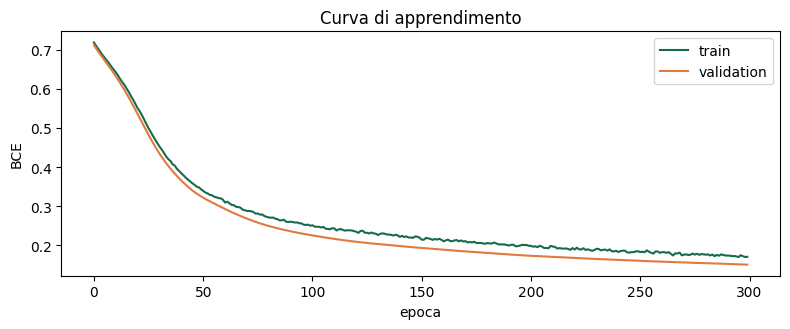

In [4]:
# BCEWithLogitsLoss combina sigmoid + binary cross entropy in modo
# numericamente stabile. Early stopping monitora la validation loss.
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()
best_loss, best_state, stale = float("inf"), None, 0
patience, max_epochs = 25, 300
history = {"train": [], "validation": []}

started = time.perf_counter()
for epoch in range(1, max_epochs + 1):
    model.train(); optimizer.zero_grad()
    train_loss = criterion(model(Xtr), Ytr)
    train_loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(Xva), Yva).item()
    history["train"].append(train_loss.item())
    history["validation"].append(val_loss)
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        stale = 0
    else:
        stale += 1
    if stale >= patience:
        break

model.load_state_dict(best_state)
print(f"Stop a epoca {epoch}; best val loss={best_loss:.4f}; tempo={time.perf_counter()-started:.1f}s")
plt.figure(figsize=(8, 3.4))
plt.plot(history["train"], label="train", color="#176B4D")
plt.plot(history["validation"], label="validation", color="#E07A3F")
plt.xlabel("epoca"); plt.ylabel("BCE"); plt.title("Curva di apprendimento"); plt.legend()
plt.tight_layout(); plt.show()

## Passo 6 — Valutare con metriche adatte al multi-label

**Obiettivo.** Non ridurre sei decisioni indipendenti a un solo
numero poco informativo.

**Cosa fa la cella.** Applica la soglia operativa 0,5 e calcola:

- **subset accuracy**, corretta solo se tutte le sei label coincidono;
- **micro-F1**, che pesa tutte le decisioni insieme;
- **macro-F1**, che assegna lo stesso peso a ogni tipo di gap;
- **Hamming loss**, quota di singole etichette sbagliate.

**Cosa osservare.** La tabella F1 per label aiuta a scoprire gap
deboli che la sola micro-F1 potrebbe nascondere.

In [5]:
# Soglia operativa fissata a 0.5, come nel backend.
model.eval()
with torch.no_grad():
    test_prob = torch.sigmoid(model(Xte)).numpy()
test_pred = (test_prob >= 0.5).astype(int)
y_true = Yte.numpy().astype(int)

subset_accuracy = float((test_pred == y_true).all(axis=1).mean())
micro_f1 = f1_score(y_true, test_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_true, test_pred, average="macro", zero_division=0)
hamming = hamming_loss(y_true, test_pred)
print(f"Subset accuracy: {subset_accuracy:.3f}")
print(f"Micro-F1: {micro_f1:.3f} · Macro-F1: {macro_f1:.3f} · Hamming loss: {hamming:.3f}")

per_label = pd.DataFrame({
    "label": LABELS,
    "F1": f1_score(y_true, test_pred, average=None, zero_division=0),
    "prevalenza_test": y_true.mean(axis=0),
}).sort_values("F1")
per_label

Subset accuracy: 0.788
Micro-F1: 0.945 · Macro-F1: 0.935 · Hamming loss: 0.040


,label,F1,prevalenza_test
4,troppe_tshirt,0.833333,0.233333
3,manca_invernale,0.928447,0.386667
2,manca_formale,0.942272,0.350667
5,poca_varieta_colori,0.956072,0.265333
0,manca_capospalla,0.974147,0.641333
1,manca_scarpe,0.977578,0.301333


## Passo 7 — Leggere il consiglio di un guardaroba

**Obiettivo.** Collegare le sei probabilità al comportamento della
pagina Impatto e del simulatore ML Lab.

**Cosa fa la cella.** Mostra per un campione test la probabilità di
ogni gap, la decisione dopo soglia e l'etichetta vera.

**Cosa osservare.** Una probabilità vicina a 0,5 è incerta; il valore
non deve diventare automaticamente un ordine di acquisto. La UI lo
traduce in un consiglio e può anche concludere che non manca nulla.

In [6]:
# Esempio leggibile: probabilità di tutti i gap per un guardaroba test.
sample = 0
result = pd.DataFrame({
    "gap": LABELS,
    "probabilità": test_prob[sample],
    "predetto": test_pred[sample].astype(bool),
    "vero": y_true[sample].astype(bool),
}).sort_values("probabilità", ascending=False)
result

,gap,probabilità,predetto,vero
0,manca_capospalla,0.995355,True,True
3,manca_invernale,0.987009,True,True
4,troppe_tshirt,0.258819,False,True
2,manca_formale,0.066756,False,False
1,manca_scarpe,0.007877,False,False
5,poca_varieta_colori,0.002320,False,False


## Passo 8 — Interpretare il risultato e dichiarare i limiti

### Cosa dire all'esame

- “Multi-label” significa più risposte vere nello stesso esempio.
- Micro-F1 pesa tutte le decisioni; macro-F1 dà pari dignità anche ai
  gap meno frequenti; subset accuracy è molto severa perché richiede
  che tutte e sei le risposte siano corrette insieme.
- Il dato sintetico deriva da regole: oggi la rete è un dimostratore
  tecnico. Il valore scientifico futuro dipende da etichette reali e
  da una definizione partecipata di “guardaroba equilibrato”.
- Il fallback a regole rende il prodotto utilizzabile e spiegabile
  anche senza checkpoint.